The statistical model that we consider is:
$$
p(x|\mu) = \frac{1}{\sqrt{2\pi}}\exp \{-{\frac{(x-\mu)^2}{2}}\}
$$
The prior distribution is $\mu \in \mathbb{R}$ (Note that it is always a good idea to tell the domain of the parameter, it matters):
$$
\varphi(\mu) = \frac{1}{\sqrt{2\pi}}\exp (-\frac{(\mu - \phi)^2}{2})
$$

In this case the marginal distribution is:

$$Z(x_1, \dots, x_n) = \frac{1}{\sqrt{n+1}} \left( \frac{1}{\sqrt{2\pi}} \right)^n \exp \left\{ -\frac{1}{2} \sum_{i=1}^n x_i^2 + \frac{1}{2(n+1)} \left( \sum_{i=1}^n x_i \right)^2 \right\}$$

This gives the posterior:
$$p(\mu|x_1, \dots, x_n) = \frac{1}{\sqrt{2\pi/(n+1)}} \exp \left\{ -\frac{n+1}{2} \left( \mu - \frac{1}{n+1} \sum_{i=1}^n x_i \right)^2 \right\} \quad (2.11)$$

Which finally gives the predictive distribution: 
$$r(x|x_1, \dots, x_n) = \frac{1}{\sqrt{2\pi \frac{n+2}{n+1}}} \exp \left\{ - \frac{1}{2 \frac{n+2}{n+1}} \left( x - \frac{1}{n+1} (\phi + \sum_{i=1}^n x_i) \right)^2 \right\} \quad (2.12)$$

Thus, it follows that the predictive is a normal distribution with mean $\frac{1}{n+1}\sum_{i=1}^nx_i$ and variance $\frac{n+2}{n+1}$. If you have been following the notes, we are going to prove these equations shortly, they are just calculations. 

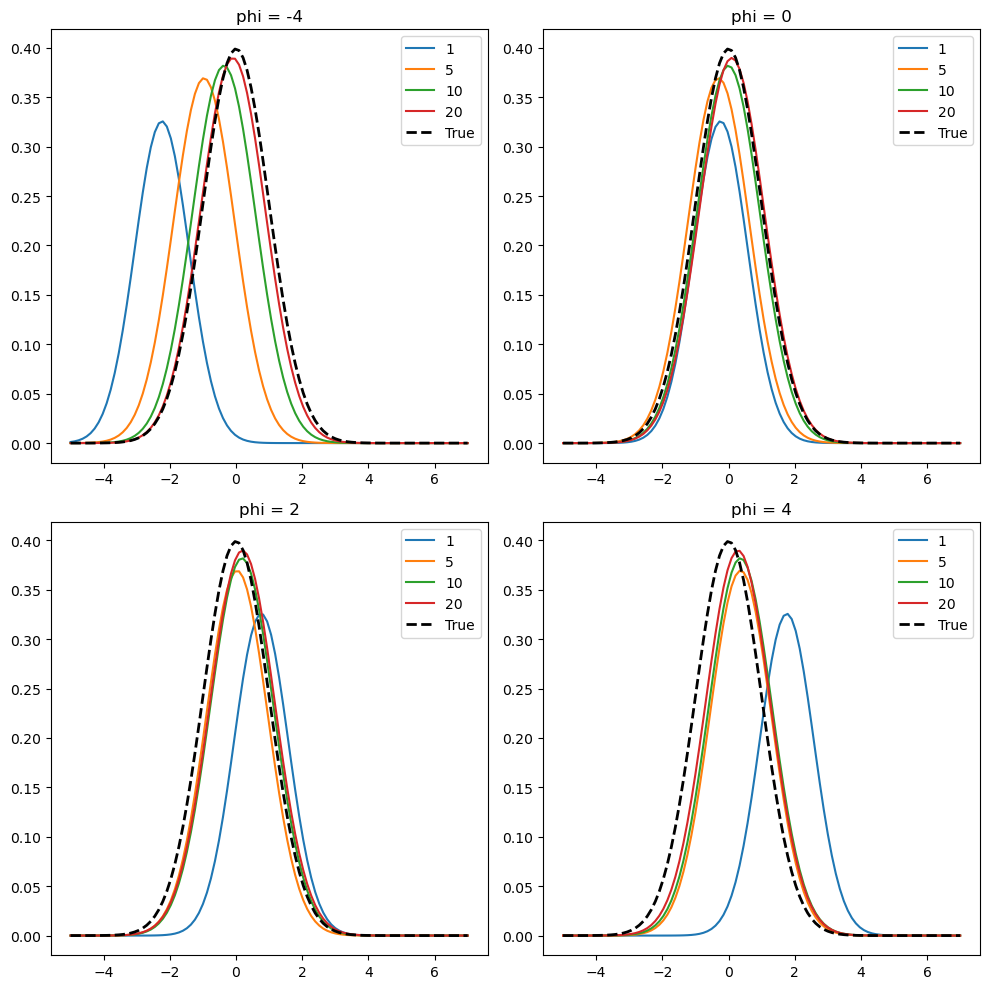

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import norm 

#Normal Distribution Function 
def f(x, mu, sig2):
    return (1/np.sqrt(2*np.pi*sig2))*np.exp(-(x - mu)**2/2*sig2)

phi_seq = np.array([-4, 0, 2, 4]) #Hyperparametric candidates 
n_seq = np.array([1, 5, 10, 20]) #candidates of n for the first n samples 

m = len(phi_seq)
l = len(n_seq)
n = 30
x = np.random.randn(n) #generate a large sample out of which the samples are considered. 
#Cannot be taking different samples for each plot!

fig, axs = plt.subplots(2, 2, figsize = (10, 10))

for i, phi in enumerate(phi_seq):
    for k in range(l):
        nn = n_seq[k]
        mu = (phi + np.sum(x[:nn]))/(nn + 1)
        sig2 = (nn + 2)/(nn + 1)
        x_vals = np.linspace(-5, 7, 100)
        y_vals = f(x_vals, mu, sig2)
        axs[i//2, i%2].plot(x_vals, y_vals, label = str(nn))
        axs[i//2, i%2].set_title(f"phi = {phi}")
    axs[i//2, i%2].plot(x_vals, norm.pdf(x_vals), linewidth = 2, linestyle = '--', color = 'black', label = 'True')
    axs[i//2, i%2].legend()

plt.tight_layout()
plt.show()
